In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("Employee retention.xls")

# Display first 10 rows
df.head()

,Unnamed: 0,First Name,Last Name,Gender,Country,Age,Date,Id
0,1,Dulce,Abril,Female,United States,32,15/10/2017,1562
1,2,Mara,Hashimoto,Female,Great Britain,25,16/08/2016,1582
2,3,Philip,Gent,Male,France,36,21/05/2015,2587
3,4,Kathleen,Hanner,Female,United States,25,15/10/2017,3549
4,5,Nereida,Magwood,Female,United States,58,16/08/2016,2468


In [3]:
print(df.shape)
print(df.columns)
print(df.info())

(1000, 8)
Index(['Unnamed: 0', 'First Name', 'Last Name', 'Gender', 'Country', 'Age',
       'Date', 'Id'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1000 non-null   int64 
 1   First Name  1000 non-null   object
 2   Last Name   1000 non-null   object
 3   Gender      1000 non-null   object
 4   Country     1000 non-null   object
 5   Age         1000 non-null   int64 
 6   Date        1000 non-null   object
 7   Id          1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


In [4]:
df.isnull().sum()

,0
Unnamed: 0,0
First Name,0
Last Name,0
Gender,0
Country,0
Age,0
Date,0
Id,0


In [7]:
# Q1: What is the age distribution of employees?

df['Age'].describe()

,Age
count,1000.000000
mean,33.260000
std,8.353573
min,21.000000
25%,26.000000
50%,32.000000
75%,38.000000
max,58.000000


##**In this case, it shows the average of age**

- Count = 1000 employees
- Mean age = 33.26 years
- Standard deviation = 8.35
- Minimum age = 21
- 25% of employees are aged 26 or younger
- Median age = 32
- 75% of employees are aged 38 or younger
- Maximum age = 58

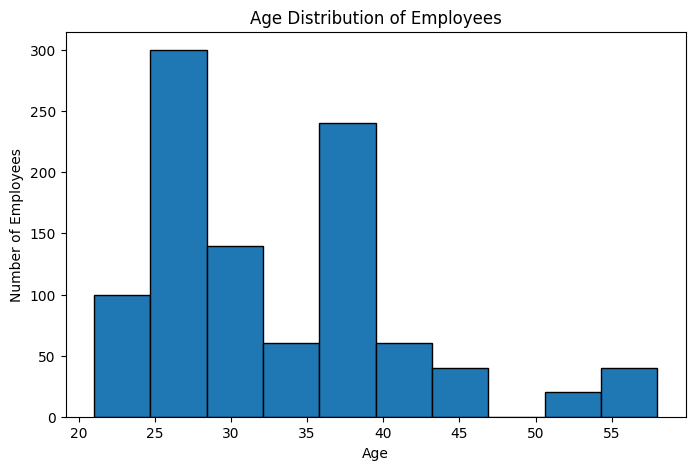

In [6]:
plt.figure(figsize=(8, 5))

plt.hist(df['Age'].dropna(), bins=10, edgecolor='black')

plt.title('Age Distribution of Employees')
plt.xlabel('Age')
plt.ylabel('Number of Employees')

plt.show()

##In the historsgram displays the 1000 employee age records

The dataset contains 1,000 employee age records. The average employee age is approximately 33 years, with ages ranging from 21 to 58. The median age is 32, indicating that half of the employees are aged 32 or below. Most employees fall between 26 and 38 years old, suggesting that the workforce is mainly made up of relatively young to middle-aged employees.

In [8]:
#Q2: What is the gender distribution of employees?

gender_count = df['Gender'].value_counts()

print(gender_count)

Gender
Female    760
Male      240
Name: count, dtype: int64


In [9]:
gender_percentage = df['Gender'].value_counts(normalize=True) * 100

print(gender_percentage)

Gender
Female    76.0
Male      24.0
Name: proportion, dtype: float64


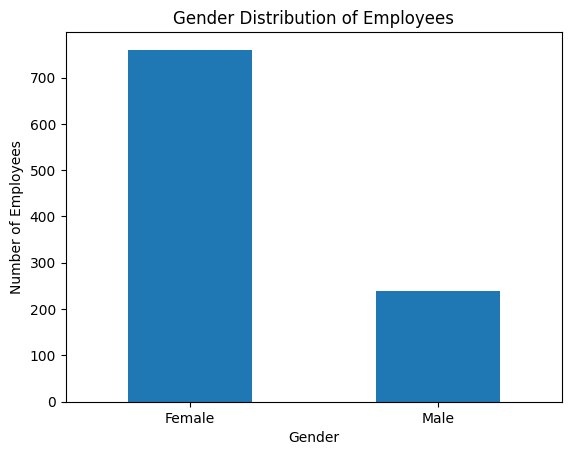

In [10]:
gender_count.plot(kind='bar')

plt.title('Gender Distribution of Employees')
plt.xlabel('Gender')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)

plt.show()

From this analysis, we can see that 76% of employees are female and 24% are male. This means the workforce is mainly female, with female employees making up more than three quarters of the total workforce.

In [15]:
#Q3: Which countries have the most employees?
country_summary = pd.DataFrame({
    'Employee Count': df['Country'].value_counts(),
    'Percentage': df['Country'].value_counts(normalize=True) * 100
})

country_summary

,Employee Count,Percentage
Country,,
United States,480,48.0
Great Britain,280,28.0
France,240,24.0


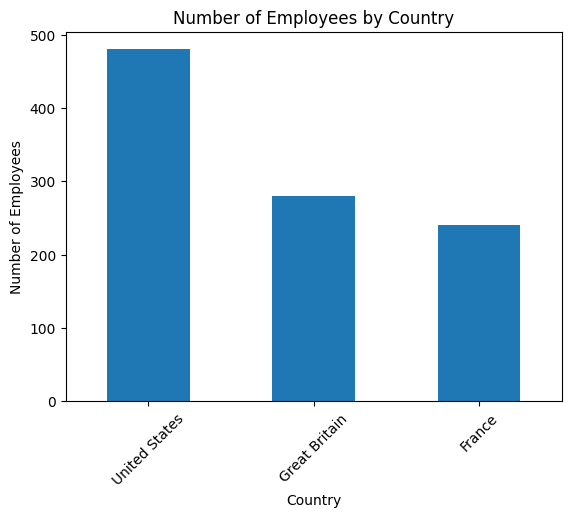

In [12]:
country_count.plot(kind='bar')

plt.title('Number of Employees by Country')
plt.xlabel('Country')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)

plt.show()

The analysis of employee distribution by country indicates that the workforce is unevenly distributed across the three countries. The United States has the highest representation, with 480 employees or 48% of the total workforce. Great Britain accounts for 28% with 280 employees, while France represents 24% with 240 employees. This suggests that the organisation has a stronger workforce presence in the United States compared with Great Britain and France.

In [21]:
#Q4: How has the number of employees changed across the recorded dates?

df['Date'] = pd.to_datetime(
    df['Date'],
    format='%d/%m/%Y',
    errors='coerce'
)

print ()

#Check

df[['Date']].head()

,Date
0,2017-10-15
1,2016-08-16
2,2015-05-21
3,2017-10-15
4,2016-08-16


In [22]:
df['Year'] = df['Date'].dt.year

In [23]:
#Count employees by year

employees_by_year = df['Year'].value_counts().sort_index()

print(employees_by_year)

Year
2015    380
2016    340
2017    280
Name: count, dtype: int64


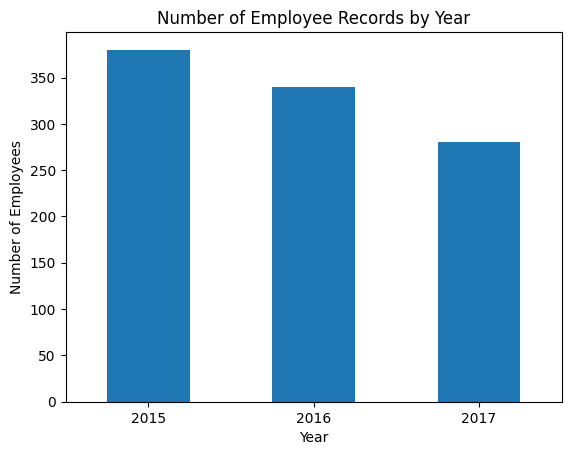

In [24]:
employees_by_year.plot(kind='bar')

plt.title('Number of Employee Records by Year')
plt.xlabel('Year')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)

plt.show()

The employee records show a clear declining pattern across the recorded dates. The dataset contains 380 records for 2015, 340 for 2016, and 280 for 2017. This represents a reduction of 40 records between 2015 and 2016 and a further reduction of 60 records between 2016 and 2017. The overall decline from 2015 to 2017 is approximately 26.3%. However, because the meaning of the Date variable is not explicitly identified as a hiring, employment, or termination date, the result should be interpreted as a decrease in the number of records associated with each year rather than definitive evidence that the company's workforce decreased.

In [33]:
#Q5: Are there duplicate employee records or IDs?

#Checking the duplicate data

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

print()

df[df.duplicated()]

#Checkig duplicate IDs

print("Checking duplicate IDs")
duplicate_ids = df['Id'].duplicated().sum()

print("Number of duplicated IDs:", duplicate_ids)


Number of duplicate rows: 0

Checking duplicate IDs
Number of duplicated IDs: 957


In [37]:
# Get the list of IDs that have duplicates and how many times they appear
id_counts = df['Id'].value_counts()

duplicate_id_list = id_counts[id_counts > 1]

print(duplicate_id_list)

Id
3265    60
3256    40
2587    40
3259    40
6125    40
5489    40
2554    20
3549    20
2468    20
1562    20
1582    20
1258    20
5486    20
6548    20
2456    20
3598    20
3579    20
2579    20
6597    20
3569    20
9654    20
8561    20
2564    20
6574    20
5555    20
5412    20
1546    20
3264    20
4569    20
6458    20
7521    20
8514    20
8563    20
8642    20
7569    20
9536    20
2567    20
2154    20
8765    20
3567    20
6540    20
2654    20
6525    20
Name: count, dtype: int64


In [38]:
#Check duplicated people

duplicate_people = df[
    df.duplicated(
        subset=['First Name', 'Last Name'],
        keep=False
    )
]

duplicate_people.sort_values(
    ['First Name', 'Last Name']
)

,Unnamed: 0,First Name,Last Name,Gender,Country,Age,Date,Id,Year
42,43,Angel,Sanor,Male,France,24,2017-10-15,3259,2017
92,93,Angel,Sanor,Male,France,24,2017-10-15,3259,2017
142,143,Angel,Sanor,Male,France,24,2017-10-15,3259,2017
192,193,Angel,Sanor,Male,France,24,2017-10-15,3259,2017
242,243,Angel,Sanor,Male,France,24,2017-10-15,3259,2017
...,...,...,...,...,...,...,...,...,...
793,794,Willodean,Harn,Female,United States,39,2016-08-16,3567,2016
843,844,Willodean,Harn,Female,United States,39,2016-08-16,3567,2016
893,894,Willodean,Harn,Female,United States,39,2016-08-16,3567,2016
943,944,Willodean,Harn,Female,United States,39,2016-08-16,3567,2016


The duplicate analysis shows that there are no completely identical rows when all columns are compared. However, there are 957 duplicated employee IDs in the dataset. This means that most employee IDs appear more than once. For example, ID 3265 appears 60 times, while several other IDs such as 3256, 2587, 3259, 6125, and 5489 appear 40 times. Many other IDs appear 20 times.